# Machine Learning: Exercise session 06

In this exercise session we will focus on Logistic regression and decision trees.

In the first problem, we will consider the [ionosphere dataset](https://www.openml.org/d/59) and fit different logistic regression models.
The goal is to predict whether a given radar signal from the ionosphere is "good" or "bad" based on 34 predictors.

In the second problem, we will focus mainly on decision trees.

In the third problem, we will derive the log-likelihood function for logistic regression.

**Note:** the third problem is theoretical and __not__ needed for the hand in.

## Problem 1

* Import the dataset `ionosphere.csv`, separate the predictors and the target variable and split it into training and test set. When you perform the splitting, set `random_state=12` and `test_size=151`.

In [112]:
# Import package/module for data
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [113]:
from sklearn.model_selection import train_test_split

dat = pd.read_csv("ionosphere.csv")
print("Original dataset shape:", dat.shape)

# Define X and Y
X = dat.drop("class", axis = 1)
y = dat["class"]

# Split into train and test dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 151, random_state = 12)

Original dataset shape: (351, 35)


* Define a `Pipeline` where you apply the `StandardScaler` and then fit a `LogisticRegression` with the following tuning parameters: `penalty="none"`, `solver="saga"`, `tol=0.1`, `random_state=10`. Call the pipeline `pipe_logistic`.

In [114]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Define the pipeline
pipe_logistic = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(penalty = "none", solver = "saga", tol = 0.1, 
                                    random_state = 10))
])

* Fit the pipeline to the training data and predict the accuracy on the training and test dataset.

In [115]:
from sklearn.metrics import accuracy_score 

# Fit pipeline to training data
pipe_logistic.fit(X_train, y_train)

# Predict pipeline to training data
y_train_pred = pipe_logistic.predict(X_train)
acc = accuracy_score(y_train, y_train_pred)
print("Logistic --- Accuracy on training:", acc)

# Predict pipeline to test data
y_test_pred = pipe_logistic.predict(X_test)
acc = accuracy_score(y_test, y_test_pred)
print("Logistic --- Accuracy on test:", np.round(acc, 3))


Logistic --- Accuracy on training: 0.895
Logistic --- Accuracy on test: 0.861


We now want to fit a logistic regression with the lasso penalty. To do that we need to choose the best regulatization parameter. 

* Define a `Kfold` object with 10 splits, and `random_state=919`. Remeber to shuffle the rows. Name the object `folds`.

In [116]:
from sklearn.model_selection import KFold
# Define folds
folds = KFold(n_splits = 10, shuffle = True, random_state = 919)

* Define a `Pipeline` where you first apply the `StandardScaler` (name this step `"scaler"`) and then fit a `LogisticRegression` (name this step `"logistic"`) with the following tuning parameters: `C=1`, `penalty="l1"`, `solver="saga"`, `tol=0.1`, `random_state=10`. Name the pipeline `pipe_logistic_l1`. What is the role of `C`? How does it compare to the tuning parameter `alpha` from `Lasso`?

In [117]:
# Define pipeline
pipe_logistic_l1 = Pipeline(
    [("scaler", StandardScaler()),
     ("logistic", LogisticRegression(C = 1, penalty = "l1", solver = "saga", tol = 0.1, random_state = 10))]
)

* Define now a `GridSearchCV` object to perform the cross-validation over a grid of different values for `C`. Fill in the `??`.

_Hint_: Choose carefully your grid, by trying out different possibility and looking at the cross-validated accuracy plot (see below). Ideally, you want a grid around the values of `C` that are "interesting".

In [118]:
from sklearn.model_selection import GridSearchCV

# Define CV object
# grid = np.logspace(-10, 10, 10)
grid = np.logspace(-2, 1, 100)
logistic_l1_cv = GridSearchCV(
    estimator=pipe_logistic_l1,
    param_grid={"logistic__C": grid},
    scoring="accuracy",
    cv=folds,
)

* Perform the cross-validation on the training data.

In [119]:
logistic_l1_cv.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=919, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('logistic',
                                        LogisticRegression(C=1, penalty='l1',
                                                           random_state=10,
                                                           solver='saga',
                                                           tol=0.1))]),
             param_grid={'logistic__C': array([ 0.01      ,  0.01072267,  0.01149757,  0.01232847,  0.01321941,
        0.01417474,  0.01519911,  0.01629751,  0.01747528,  0.01873817,
        0.02...
        0.93260335,  1.        ,  1.07226722,  1.149757  ,  1.23284674,
        1.32194115,  1.41747416,  1.51991108,  1.62975083,  1.7475284 ,
        1.87381742,  2.009233  ,  2.15443469,  2.3101297 ,  2.47707636,
        2.65608778,  2.84803587,  3.05385551,  3.27454916,  3.51119173,
        3.76493581,  4.03701726,  4.32876128,  4.64158883,  4.97702356,
        5.33669923,  5.72236766,  6.13590727,  6.57933225,  7.05480231,
        7.56463328,  8.11130831,  8.69749003,  9.32603347, 10.        ])},
             scoring='accuracy')

* Plot the results of the cross-validation by filling in the `??`.

_Note_: Notice that we want to compute the best model according to the __1-se rule__. To do that, we need to compute the standard error of the __mean__ cross-validated accuracy. This is obtained by dividing the standard deviations by the square root of $K = 10$ (i.e., number of folds).

In [120]:
pd.DataFrame(logistic_l1_cv.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_logistic__C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.012277,0.023923,0.001305,0.000783,0.01,{'logistic__C': 0.01},0.65,0.75,0.60,0.75,0.6,0.6,0.50,0.65,0.45,0.6,0.615,0.089582,90
1,0.003304,0.000479,0.001300,0.000459,0.010723,{'logistic__C': 0.010722672220103232},0.65,0.75,0.60,0.75,0.6,0.6,0.50,0.65,0.45,0.6,0.615,0.089582,90
2,0.003510,0.000542,0.001411,0.000668,0.011498,{'logistic__C': 0.011497569953977356},0.65,0.75,0.60,0.75,0.6,0.6,0.50,0.65,0.45,0.6,0.615,0.089582,90
3,0.003457,0.000624,0.001307,0.000654,0.012328,{'logistic__C': 0.012328467394420659},0.65,0.75,0.60,0.75,0.6,0.6,0.50,0.65,0.45,0.6,0.615,0.089582,90
4,0.003377,0.000775,0.001380,0.000797,0.013219,{'logistic__C': 0.013219411484660288},0.65,0.75,0.60,0.75,0.6,0.6,0.50,0.65,0.45,0.6,0.615,0.089582,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.003605,0.000958,0.001268,0.000491,7.564633,{'logistic__C': 7.56463327554629},0.85,0.80,0.85,1.00,0.9,0.8,0.85,0.95,0.70,0.8,0.850,0.080623,48
96,0.003840,0.001077,0.001183,0.000368,8.111308,{'logistic__C': 8.111308307896872},0.85,0.80,0.85,1.00,0.9,0.8,0.85,0.95,0.70,0.8,0.850,0.080623,48
97,0.003200,0.000399,0.001100,0.000300,8.69749,{'logistic__C': 8.697490026177835},0.85,0.80,0.85,1.00,0.9,0.8,0.85,0.95,0.70,0.8,0.850,0.080623,48
98,0.003500,0.000670,0.001200,0.000400,9.326033,{'logistic__C': 9.326033468832199},0.85,0.80,0.85,1.00,0.9,0.8,0.85,0.95,0.70,0.8,0.850,0.080623,48


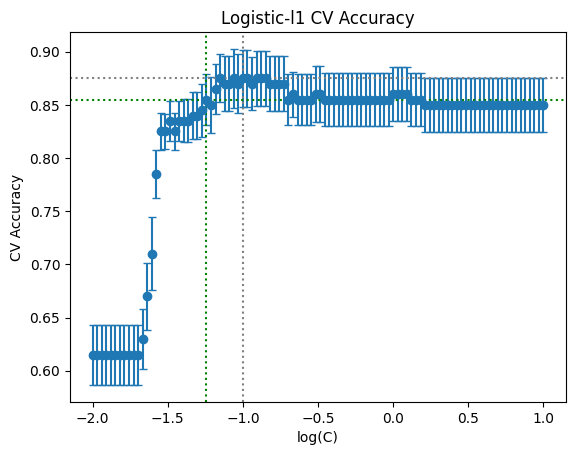

In [121]:
# Plot results of cross-validation
cv_res = logistic_l1_cv.cv_results_

mean_scores = cv_res["mean_test_score"]
se_scores = cv_res["std_test_score"] / np.sqrt(logistic_l1_cv.n_splits_) # ! very important to divide by sqrt(# folds)
params = cv_res["param_logistic__C"].data

best_index = np.argmax(mean_scores)

one_se_best_param = np.min(
    grid[mean_scores >= mean_scores[best_index] - se_scores[best_index]]
)

one_se_score = mean_scores[grid == one_se_best_param][0]

# just for reference, we also plot the parameter that maximizes the cross-validated accuracy
best_param = logistic_l1_cv.best_params_["logistic__C"] 
best_score = logistic_l1_cv.best_score_

plt.errorbar(x=np.log10(grid), y=mean_scores, yerr=se_scores, fmt="o", capsize=3)

# plt.errorbar(x=(grid), y=mean_scores, yerr=se_scores, fmt="o", capsize=3)
# plt.xscale('log')

plt.axvline(
    np.log10(best_param), ls="dotted", color="grey"
)  # vertical line at the parameter value yielding highest accuracty
plt.axhline(
    best_score, ls="dotted", color="grey"
)  # horizontal line at highest accuracy
plt.axvline(
    np.log10(one_se_best_param), ls="dotted", color="green"
)  # vertical line at the parameter corresponding to 1-se
plt.axhline(
    one_se_score, ls="dotted", color="green"
)  # horizontal line at corresponding to 1-se parameter

plt.title("Logistic-l1 CV Accuracy")
plt.xlabel("log(C)")
plt.ylabel("CV Accuracy")
plt.show()

In [122]:
pipe_logistic_l1.set_params(logistic__C = 10 ** (-8))
pipe_logistic_l1.fit(X_train, y_train)
logEst = pipe_logistic_l1.named_steps['logistic']
logEst.coef_

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.]])

* Finally, refit the __1-se rule__ model to the whole training dataset, and compute the accuracy on the training and test dataset.

In [123]:
# Take best model
pipe_logistic_l1.set_params(logistic__C = one_se_best_param, logistic__penalty = "l1")

# Fit on training data
pipe_logistic_l1.fit(X_train, y_train)

# Predict on training
y_pred = pipe_logistic_l1.predict(X_train)
acc = accuracy_score(y_train, y_pred)
print("Logistic l1 --- Accuracy on training:", acc)

# Predict on test
y_pred = pipe_logistic_l1.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Logistic l1 --- Accuracy on test:", np.round(acc, 3))

Logistic l1 --- Accuracy on training: 0.855
Logistic l1 --- Accuracy on test: 0.821


* Does this model perform better than the unregularized logistic regression? What are the advantages of this model?

In [124]:
# Model interpretability
print("Logistic --- Number of predictors:", np.sum(pipe_logistic["logistic"].coef_ != 0))
print("Logistic l1 --- Number of predictors:", np.sum(pipe_logistic_l1["logistic"].coef_ != 0))

Logistic --- Number of predictors: 33
Logistic l1 --- Number of predictors: 5


In [125]:
# To extract names of significant predictors
ind_logistic = (pipe_logistic["logistic"].coef_ != 0).ravel()
ind_logistic_pen = (pipe_logistic_l1["logistic"].coef_ != 0).ravel()
cols = X_train.columns.to_numpy()
cols[ind_logistic]
cols[ind_logistic_pen]

array(['a01', 'a03', 'a05', 'a07', 'a08'], dtype=object)

## Problem 2

In [126]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, train_test_split, GridSearchCV

### 2.0 Data import and Cleaning

Import the "Heart" dataset, containing demographic and medical informations about a list of patients. Drop `NA` values, convert the categorical variables into the desired pandas type: "category", and perform any other necessary data cleaning.

In [127]:
heart = pd.read_csv('Heart_ISL.csv', index_col=0).dropna().reset_index(drop=True).astype({
    'ChestPain': 'category',
    'Thal': 'category',
    'AHD': 'category',
})
heart.info()
heart.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Age        297 non-null    int64   
 1   Sex        297 non-null    int64   
 2   ChestPain  297 non-null    category
 3   RestBP     297 non-null    int64   
 4   Chol       297 non-null    int64   
 5   Fbs        297 non-null    int64   
 6   RestECG    297 non-null    int64   
 7   MaxHR      297 non-null    int64   
 8   ExAng      297 non-null    int64   
 9   Oldpeak    297 non-null    float64 
 10  Slope      297 non-null    int64   
 11  Ca         297 non-null    float64 
 12  Thal       297 non-null    category
 13  AHD        297 non-null    category
dtypes: category(3), float64(2), int64(9)
memory usage: 27.0 KB


,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


The response variable that we will try to predict is "AHD", that indicates whether the patient has a heart disease.

Now split the data into the features `X` and the response `y`.

As, sadly, trees in sklearn do not handle categorical features directly, transform `X`'s categorical variables into "dummies". This can be achieved either with panda's `pd.get_dummies(<data>, drop_first=True)` or sklearn's `OneHotEncoder`. Make sure that you keep X in dataframe format, and keep feature/column names.

In [128]:
X = pd.get_dummies(heart.drop("AHD", axis=1), drop_first=True)
y = heart["AHD"]

Split the data into train and test. Set random_state=40 and leave 20% of the data out for the test set.

In [129]:
# Split into train and test dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 40)

### 2.1 Unpruned tree

In [130]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

Begin by fitting a (unpruned) classification tree to the training data, in order to predict whether each patient potentially has AHD, based on his available demographic and medical information. Use either the Gini index or the entropy as a splitting criterion, as you prefer.

In [131]:
tree_full = DecisionTreeClassifier(criterion='entropy')#gini entropy
tree_full.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

Now plot the tree using sklearn's `plot_tree` function

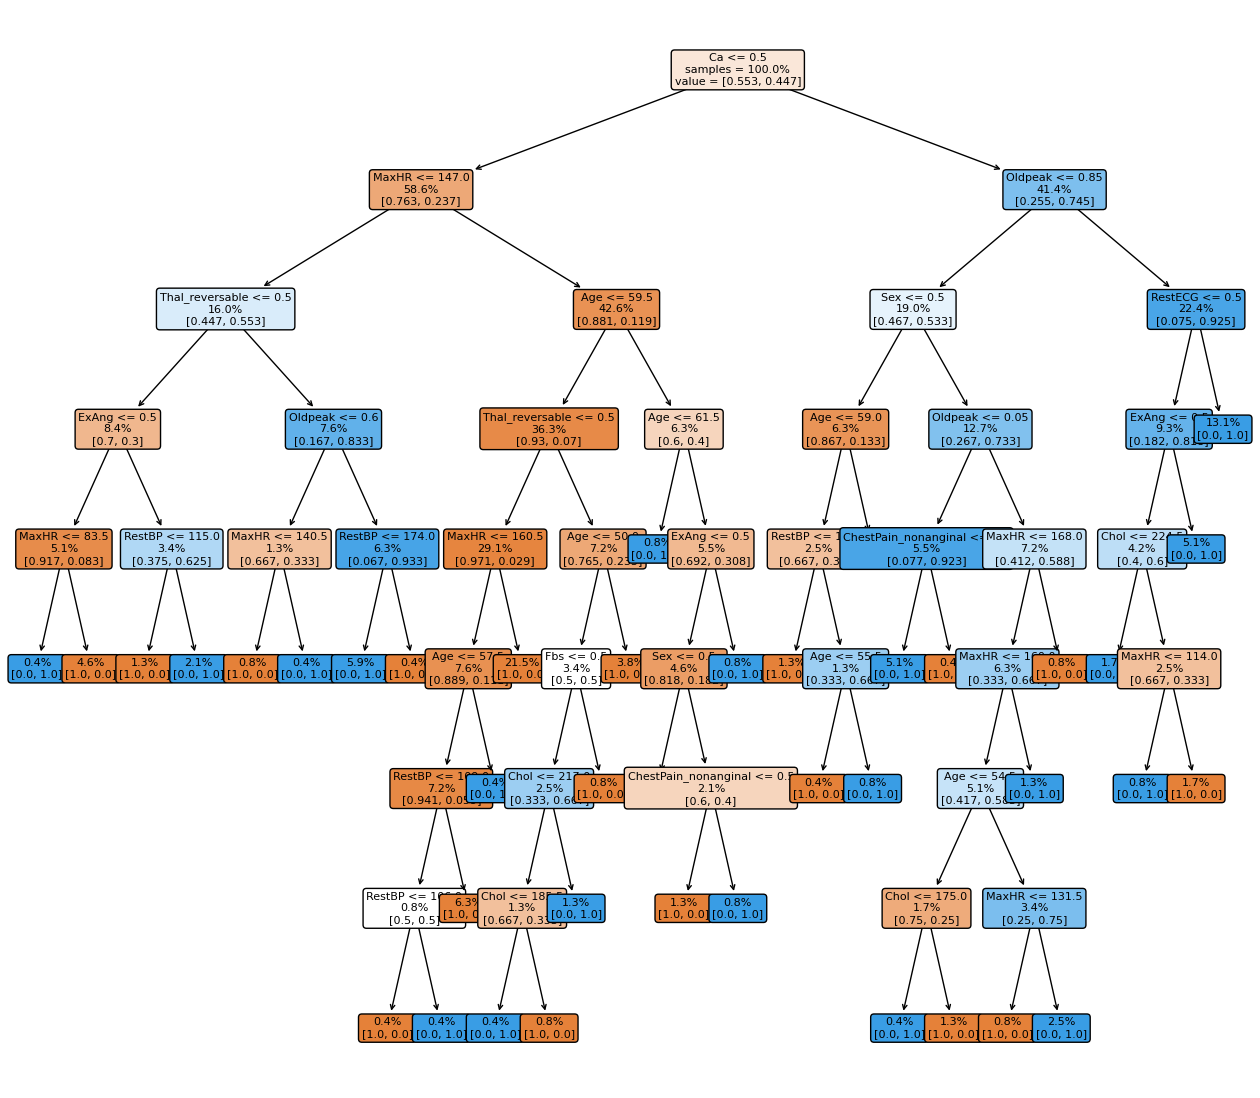

In [132]:
plt.figure(figsize=(16,14))
plot_tree(tree_full, feature_names=X_train.columns.tolist(), impurity=False, label="root",
          filled=True, proportion=True, rounded=True, fontsize=8)
plt.show()

Could you use only this image to predict the "AHD" variable for the observations left out in the test set?

Now check the model's training and test accuracy (or score). What do you observe and why ?

In [133]:
print("Train accuracy:", tree_full.score(X_train,y_train))
print("Test accuracy:", tree_full.score(X_test,y_test))

Train accuracy: 1.0
Test accuracy: 0.7333333333333333


### 2.2 Cost-complexity pruning

Remember that the flexibility of a decision tree can be tuned by pruning it via cost-complexity pruning.

Use cross-validation to select the best cost-complexity hyper-parameter $\alpha$ value. Then, plot the tree coresponding to the best $\alpha$ value.

In [134]:
path = tree_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [135]:
grid_alphas = ccp_alphas
grid_alphas = np.logspace(-5, 1, 100)

In [136]:
folds = KFold(n_splits = 10, shuffle = True, random_state = 1)
tree_full = DecisionTreeClassifier(criterion = "entropy", ccp_alpha = 0)
hyper_params = {"ccp_alpha": grid_alphas}
treeCV = GridSearchCV(estimator = tree_full,
                      param_grid = hyper_params,
                      cv = folds)

In [137]:
treeCV.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=1, shuffle=True),
             estimator=DecisionTreeClassifier(ccp_alpha=0, criterion='entropy'),
             param_grid={'ccp_alpha': array([1.00000000e-05, 1.14975700e-05, 1.32194115e-05, 1.51991108e-05,
       1.74752840e-05, 2.00923300e-05, 2.31012970e-05, 2.65608778e-05,
       3.05385551e-05, 3.51119173e-05, 4.03701726e-05, 4.64158883e-05,
       5.33669923...
       4.03701726e-01, 4.64158883e-01, 5.33669923e-01, 6.13590727e-01,
       7.05480231e-01, 8.11130831e-01, 9.32603347e-01, 1.07226722e+00,
       1.23284674e+00, 1.41747416e+00, 1.62975083e+00, 1.87381742e+00,
       2.15443469e+00, 2.47707636e+00, 2.84803587e+00, 3.27454916e+00,
       3.76493581e+00, 4.32876128e+00, 4.97702356e+00, 5.72236766e+00,
       6.57933225e+00, 7.56463328e+00, 8.69749003e+00, 1.00000000e+01])})

In [138]:
pd.DataFrame(treeCV.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_ccp_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.002762,0.001317,0.001193,0.000384,0.00001,{'ccp_alpha': 1e-05},0.666667,0.750000,0.791667,0.708333,0.708333,0.583333,0.791667,0.782609,0.782609,0.695652,0.726087,0.064054,22
1,0.001759,0.000533,0.001102,0.000524,0.000011,{'ccp_alpha': 1.1497569953977357e-05},0.708333,0.708333,0.708333,0.750000,0.708333,0.625000,0.708333,0.782609,0.782609,0.695652,0.717754,0.043575,39
2,0.001999,0.000455,0.001092,0.000287,0.000013,{'ccp_alpha': 1.3219411484660286e-05},0.666667,0.708333,0.791667,0.666667,0.708333,0.666667,0.708333,0.782609,0.782609,0.739130,0.722101,0.047159,29
3,0.001976,0.000362,0.000900,0.000300,0.000015,{'ccp_alpha': 1.5199110829529332e-05},0.666667,0.708333,0.750000,0.708333,0.666667,0.625000,0.708333,0.739130,0.826087,0.695652,0.709420,0.052073,46
4,0.001300,0.000458,0.000900,0.000539,0.000017,{'ccp_alpha': 1.747528400007683e-05},0.666667,0.750000,0.750000,0.666667,0.708333,0.541667,0.708333,0.695652,0.782609,0.782609,0.705254,0.067692,51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.002010,0.000716,0.000894,0.000299,5.722368,{'ccp_alpha': 5.72236765935022},0.541667,0.666667,0.500000,0.666667,0.416667,0.416667,0.458333,0.652174,0.695652,0.521739,0.553623,0.102991,73
96,0.001877,0.000796,0.000960,0.000648,6.579332,{'ccp_alpha': 6.5793322465756825},0.541667,0.666667,0.500000,0.666667,0.416667,0.416667,0.458333,0.652174,0.695652,0.521739,0.553623,0.102991,73
97,0.001892,0.000688,0.000807,0.000404,7.564633,{'ccp_alpha': 7.56463327554629},0.541667,0.666667,0.500000,0.666667,0.416667,0.416667,0.458333,0.652174,0.695652,0.521739,0.553623,0.102991,73
98,0.002104,0.000300,0.000792,0.000399,8.69749,{'ccp_alpha': 8.697490026177835},0.541667,0.666667,0.500000,0.666667,0.416667,0.416667,0.458333,0.652174,0.695652,0.521739,0.553623,0.102991,73


In [139]:
resCV = treeCV.cv_results_

test_Misclasif = 1 - resCV["mean_test_score"]
std_mean_err_test = resCV["std_test_score"] / np.sqrt(10)
alpha_grid = resCV["param_ccp_alpha"].data

index_best = treeCV.best_index_
best_alpha = treeCV.best_params_["ccp_alpha"]
one_se_rule_best_alpha = np.max(alpha_grid[test_Misclasif <= test_Misclasif[index_best] + std_mean_err_test[index_best]])

print("Best alpha:", best_alpha)
print("Best 1se alpha:", one_se_rule_best_alpha)

Best alpha: 0.02848035868435802
Best 1se alpha: 0.037649358067924674


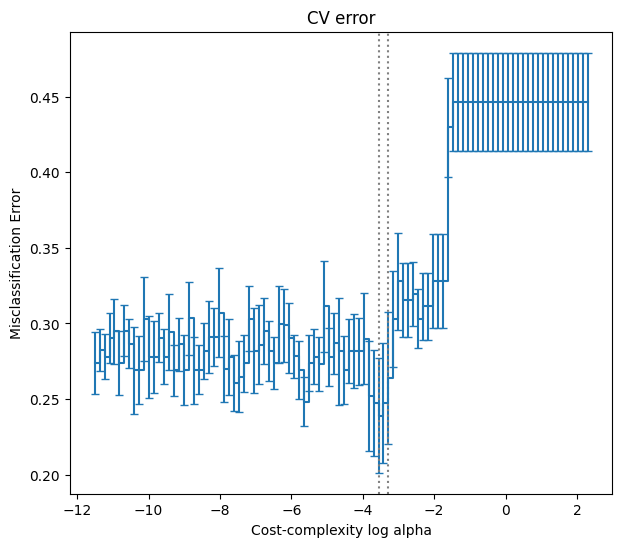

In [140]:
plt.figure(figsize=(7,6))
plt.errorbar(x=np.log(grid_alphas), y=test_Misclasif, yerr=std_mean_err_test, capsize=3, drawstyle="steps-post")#, fmt='o'

plt.axvline(np.log(best_alpha), ls='dotted', color="grey")#vertical line at the k yielding minimum CV MSE
plt.axvline(np.log(one_se_rule_best_alpha), ls='dotted', color="grey")#vertical line at best k value according to 1 std err rule

plt.title("CV error")
plt.xlabel('Cost-complexity log alpha')
plt.ylabel('Misclassification Error')
plt.show()

In [141]:
tree_best = treeCV.best_estimator_
#or:
tree_best_1se = DecisionTreeClassifier(criterion='entropy', ccp_alpha=one_se_rule_best_alpha).fit(X_train,y_train)

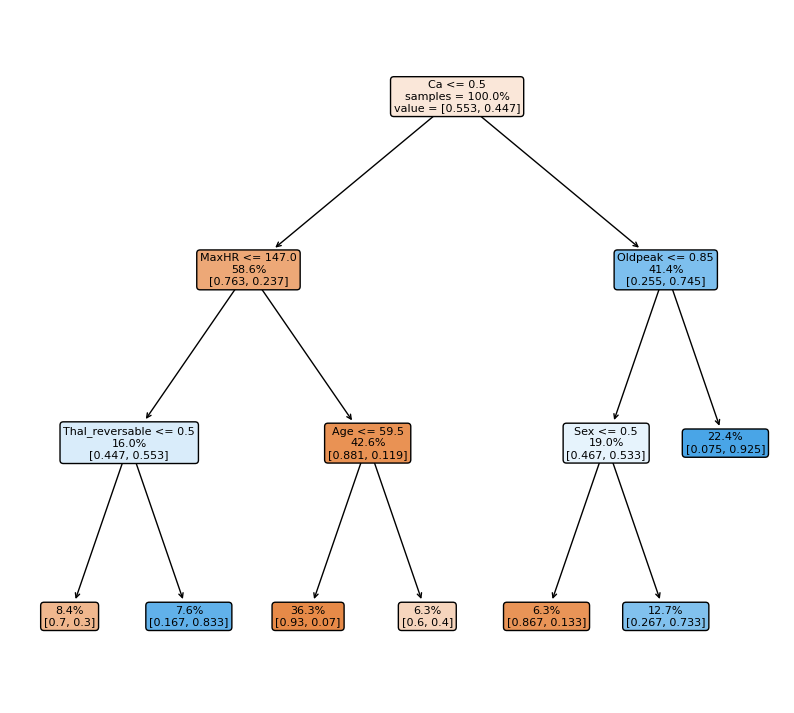

In [142]:
plt.figure(figsize=(10,9))
plot_tree(tree_best, feature_names=X_train.columns.tolist(), impurity=False, label="root",
          filled=True, proportion=True, rounded=True, fontsize=8)
plt.show()

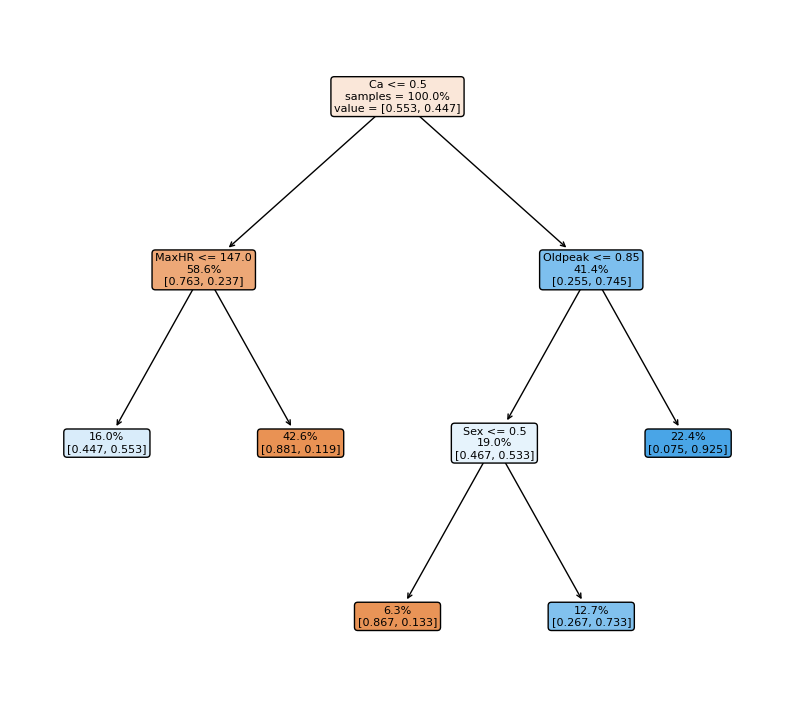

In [143]:
plt.figure(figsize=(10,9))
plot_tree(tree_best_1se, feature_names=X_train.columns.tolist(), impurity=False, label="root",
          filled=True, proportion=True, rounded=True, fontsize=8)
plt.show()

## Problem 3 (not to hand in)

Suppose we have independent observations $(x_1,y_1),\dots, (x_n,y_n)$ from $(X,Y)$ with $x_i \in \mathbb R^p$, and $y_i \in \{0,1\}$,  $i = 1, \dots, n$.
Further assume that the conditional distribution of $Y$ given $X= x$ is Bernoulli with success probability denoted as:
  $$ \mathbb P(Y = 1 \mid X = x) = 1 - \mathbb P(Y = 0 \mid X = x) = \sigma(x^\top \beta),$$
where $\sigma: \mathbb R \to [0, 1]$, and
  $$
  \sigma(a) = \dfrac{e^{a}}{1 + e^{a}}, \quad a\in \mathbb R.
$$
Show that the log-likelihood of the parameter vector $\beta\in\mathbb R^p$ is
  $$\ell(\beta) = \sum_{i=1}^n y_i x_i^\top \beta - \log(1 + e^{x_i^\top \beta}).$$

### Solution

The goal is to estimate the conditional probabilities of $Y_i$ given the predictor $X_i = x_i$, i.e.,

\begin{align}
\mathbb P(Y_i = 1 \mid X_i = x_i) = 1 - \mathbb P(Y_i = 0 \mid X_i = x_i) = \sigma(x_i^T\beta) =: p_i(x_i),
\end{align}

which is a function of the predictors $x_i \in \mathbb R^p$, $i = 1, \dots, n$.

Assuming that the conditional distribution of $Y_i$ given $X_i = x_i$ follows a Bernoulli with probability of success $p_i(x_i)$, we can write its probability mass function as

\begin{align}
\mathbb P(Y_i = y_i \mid X_i = x_i) = p_i(x_i)^{y_i} (1 - p_i(x_i))^{1 - y_i},
\end{align}

where $y_i \in \{0, 1\}$ and $i = 1, \dots, n$.

The likelihood function is written as

\begin{align}
L(\beta) 
= &\ \mathbb P(Y_1 = y_1, \dots, Y_n = y_n \mid X_1 = x_1, \dots, X_n = x_n)\\
= &\ \mathbb P(Y_1 = y_1 \mid X_1 = x_1) \times \dots \times \mathbb P(Y_n = y_n \mid X_n = x_n)\\
= &\ \prod_{i=1}^{n} P(Y_i = y_i \mid X_i = x_i) = \prod_{i=1}^{n} p_i(x_i)^{y_i} (1 - p_i(x_i))^{1 - y_i}.
\end{align}

Notice that the likelihood function depends on the parameter vector $\beta \in \mathbb R^p$ because we model the probabilities as $p_i(x_i) = \sigma(x_i^T\beta)$. 

The log-likelihood is therefore defined as

\begin{align}
\ell(\beta) 
= &\ \log L(\beta) = \log \left(\prod_{i=1}^{n} p_i(x_i)^{y_i} (1 - p_i(x_i))^{1 - y_i}\right)\\
= &\ \sum_{i=1}^{n} \log\left(p_i(x_i)^{y_i} (1 - p_i(x_i))^{1 - y_i}\right)\\
= &\ \sum_{i=1}^{n} \underbrace{y_i}_{\text{true}\\ \text{class}} \log \underbrace{p_i(x_i)}_{\text{predicted}\\ \text{probability}} +
\underbrace{(1 - y_i)}_{\text{true}\\ \text{class}} \log \underbrace{(1 - p_i(x_i))}_{\text{predicted}\\ \text{probability}}.
\end{align}

Notice that the last formulation above corresponds to the __(negative) cross-entropy__, a loss function commonly used in machine learning.

By plugging-in the definition of $p_i(x_i) := \sigma(x_i^T\beta) = \frac{1}{(1 + e^{-x_i^T \beta})}$, we get

\begin{align}
\ell(\beta)
= &\ \sum_{i=1}^{n} y_i \log p_i(x_i) + (1 - y_i) \log (1 - p_i(x_i))\\
= &\ \sum_{i=1}^{n} y_i \log \left(\frac{1}{1 + e^{-x_i^T \beta}}\right) + (1 - y_i) \log\left(\frac{e^{-x_i^T\beta}}{1 + e^{-x_i^T \beta}}\right)\\
= &\ \sum_{i=1}^{n} y_i \left[- \log(1 + e^{-x_i^T \beta}) - \log(e^{-x_i^T \beta}) + \log(1 + e^{-x_i^T \beta}) \right] + \log \left(\frac{e^{-x_i^T\beta}}{1 + e^{-x_i^T \beta}}\right)\\
= &\ \sum_{i=1}^{n} y_ix_i^T \beta + \log \left(\frac{e^{-x_i^T\beta}}{1 + e^{-x_i^T \beta}}\right)\\
= &\ \sum_{i=1}^{n} y_ix_i^T \beta + \log \left(\frac{1}{1 + e^{x_i^T \beta}}\right)\\
= &\ \sum_{i=1}^{n} y_ix_i^T \beta - \log \left(1 + e^{x_i^T \beta}\right).
\end{align}

Therefore, when we fit a logistic regression model, we want to find the parameters $\beta$ that maximize the log-likelihood, i.e., 

\begin{align*}
\beta^* = \arg\max_\beta \sum_{i=1}^{n} y_ix_i^T \beta - \log \left(1 + e^{x_i^T \beta}\right).
\end{align*}

There is no analytical solution for the optimal parameter $\beta^*$. However, $\beta^*$ can be found with numerical methods.